In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, "../src")
from utils.fashionpedia import build_garments, build_images, load_json, load_yaml

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

SPLIT = "val"  # "val" or "train"
DATA = Path("../data/fashionpedia")
ANNOTATIONS = DATA / f"annotations/instances_attributes_{SPLIT}2020.json"
IMAGE_DIR = DATA / ("images/train" if SPLIT == "train" else "images/test")  # val images are unzipped into test/

In [2]:
raw = load_json(ANNOTATIONS)
mapping = load_yaml("../configs/fashionpedia_map.yaml")
taxonomy = load_yaml("../configs/taxonomy.yaml")

garments = build_garments(raw, mapping, taxonomy)
images = build_images(raw)
print(f"{len(raw['annotations']):,} Fashionpedia objects -> {len(garments):,} garments in {garments.image_id.nunique():,} images")

8,781 Fashionpedia objects -> 4,669 garments in 1,158 images


In [3]:
images

,image_id,file_name,width,height,aspect
0,13297,e14733841b04c64e75789a91fbe549b3.jpg,771,1024,0.752930
1,18074,b4f6d9c2696573ff0cfc05070d17b5b6.jpg,1024,680,1.505882
2,10330,8075d3afc3d574f8cfd7c5400417d9fc.jpg,1024,682,1.501466
3,9468,32e566cd7c0388f44f1a09e10e2ac96c.jpg,1024,682,1.501466
4,17856,0229bef01efc25f915374d55f59cbfdd.jpg,1024,768,1.333333
...,...,...,...,...,...
1153,9692,fd567ffad275955ac945eeeacc1fdac5.jpg,680,1024,0.664062
1154,18111,f8ae096bdaa82b15d61981380993c560.jpg,880,1024,0.859375
1155,10645,fdcd3232350a031d96aae02b069b7f88.jpg,460,1024,0.449219
1156,10850,97798485ca538a03284d8dbaceab92c4.jpg,681,1024,0.665039


In [4]:
## Building lookups for fashionpedia
print(raw.keys())
print(raw["attributes"])

img_names = {i["id"]: i["file_name"] for i in raw["images"]}
category_names = {c["id"]: c["name"] for c in raw["categories"]}
attr_names = {a["id"]: a["name"] for a in raw["attributes"]}


dict_keys(['info', 'categories', 'attributes', 'licenses', 'annotations', 'images'])
[{'id': 0, 'name': 'classic (t-shirt)', 'supercategory': 'nickname', 'level': 1, 'taxonomy_id': 'att000002_00'}, {'id': 1, 'name': 'polo (shirt)', 'supercategory': 'nickname', 'level': 1, 'taxonomy_id': 'att000003_00'}, {'id': 2, 'name': 'undershirt', 'supercategory': 'nickname', 'level': 1, 'taxonomy_id': 'att000004_00'}, {'id': 3, 'name': 'henley (shirt)', 'supercategory': 'nickname', 'level': 1, 'taxonomy_id': 'att000005_00'}, {'id': 4, 'name': 'ringer (t-shirt)', 'supercategory': 'nickname', 'level': 1, 'taxonomy_id': 'att000006_00'}, {'id': 5, 'name': 'raglan (t-shirt)', 'supercategory': 'nickname', 'level': 1, 'taxonomy_id': 'att000007_00'}, {'id': 6, 'name': 'rugby (shirt)', 'supercategory': 'nickname', 'level': 1, 'taxonomy_id': 'att000008_00'}, {'id': 7, 'name': 'sailor (shirt)', 'supercategory': 'nickname', 'level': 1, 'taxonomy_id': 'att000009_00'}, {'id': 8, 'name': 'crop (top)', 'supercate

In [5]:
garments.head()

,image_id,ann_id,fp_category,category,subtype,area,area_frac,bbox_x,bbox_y,bbox_w,bbox_h,img_w,img_h,fit,pattern,length,silhouette,waist_rise,material,sleeve_length,neckline,n_sleeves,n_necklines,outfit_role
0,17039,2,coat,outerwear,puffer,37339,0.053466,392.0,407.0,241.0,274.0,1024,682,regular,solid,NaN,NaN,NaN,NaN,long,NaN,2,0,outer
1,17039,3,scarf,accessory,scarf,5102,0.007306,460.0,389.0,136.0,109.0,1024,682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,accessory
2,17039,5,"bag, wallet",bag,bag,1475,0.002112,439.0,449.0,156.0,145.0,1024,682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,bag
3,17039,6,glove,accessory,glove,1733,0.002481,442.0,618.0,50.0,55.0,1024,682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,accessory
4,17039,7,glove,accessory,glove,100,0.000143,584.0,674.0,30.0,7.0,1024,682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,accessory


In [6]:
# every garment must have one of our categories and an outfit role
assert set(garments.category) <= set(taxonomy["categories"])
assert garments.outfit_role.notna().all()
garments.dtypes

image_id           int64
ann_id             int64
fp_category          str
category             str
subtype              str
area               int64
area_frac        float64
bbox_x           float64
bbox_y           float64
bbox_w           float64
bbox_h           float64
img_w              int64
img_h              int64
fit                  str
pattern              str
length               str
silhouette           str
waist_rise           str
material             str
sleeve_length     object
neckline          object
n_sleeves          int64
n_necklines        int64
outfit_role          str
dtype: object

### Class distribution after mapping
Which classes are rare, and which have no data at all?

In [7]:
counts = pd.DataFrame({
    "garments": garments.category.value_counts(),
    "images": garments.groupby("category").image_id.nunique(),
})
counts["share_%"] = (100 * counts.garments / counts.garments.sum()).round(1)
missing = set(taxonomy["categories"]) - set(counts.index)
print("categories with no data:", missing or "none")
counts

categories with no data: none


,garments,images,share_%
category,,,
accessory,852,527,18.2
bag,214,205,4.6
dress,529,527,11.3
outerwear,314,304,6.7
pants,420,419,9.0
shirt,102,102,2.2
shoes,1566,804,33.5
skirt,162,162,3.5
top,510,489,10.9


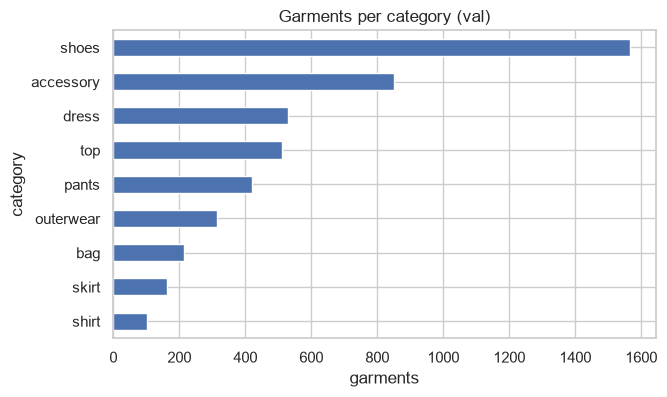

In [8]:
ax = counts.garments.sort_values().plot.barh(figsize=(7, 4), title=f"Garments per category ({SPLIT})")
ax.set_xlabel("garments");

### Subtypes per category
How often do we get a subtype, and which ones?

In [9]:
sub_cov = garments.groupby("category").subtype.apply(lambda s: s.notna().mean()).rename("has_subtype").round(2)
sub_cov.to_frame()

,has_subtype
category,
accessory,1.00
bag,1.00
dress,1.00
outerwear,1.00
pants,0.76
shirt,0.00
shoes,1.00
skirt,1.00
top,0.69


In [10]:
for cat, g in garments.groupby("category"):
    vc = g.subtype.value_counts()
    print(f"{cat:10} {vc.head(8).to_dict()}")

accessory  {'belt': 164, 'glasses': 130, 'tights': 122, 'hair_accessory': 109, 'sock': 87, 'watch': 84, 'hat': 74, 'scarf': 48}
bag        {'bag': 214}
dress      {'dress': 374, 'gown': 97, 'jumpsuit': 21, 'shirt_dress': 17, 'sweater_dress': 12, 'sundress': 8}
outerwear  {'coat': 86, 'blazer': 68, 'biker_jacket': 37, 'jacket': 34, 'vest': 22, 'denim_jacket': 17, 'track_jacket': 16, 'trench_coat': 12}
pants      {'jeans': 109, 'leggings': 90, 'shorts': 90, 'lounge_shorts': 9, 'bermuda_shorts': 7, 'culottes': 6, 'sweat_pants': 4, 'capri': 3}
shirt      {}
shoes      {'shoe': 1566}
skirt      {'pencil_skirt': 74, 'skirt': 27, 'skater_skirt': 27, 'full_skirt': 26, 'pleated_skirt': 6, 'wrap_skirt': 2}
top        {'t-shirt': 150, 'tank_top': 78, 'camisole': 46, 'crop_top': 36, 'sweater': 21, 'cardigan': 12, 'hoodie': 7, 'polo': 2}


In [11]:
# subtypes in the taxonomy that never appear in the data
seen = set(garments.subtype.dropna())
{cat: [s for s in subs if s not in seen] for cat, subs in taxonomy["categories"].items() if any(s not in seen for s in subs)}

{'shirt': ['shirt', 'blouse'],
 'top': ['sweatshirt'],
 'pants': ['trousers',
  'tuxedo_pants',
  'chinos',
  'khakis',
  'linen_pants',
  'joggers',
  'cargo_shorts'],
 'shoes': ['sneakers', 'formal_shoes', 'loafers', 'canvas_shoe'],
 'bag': ['wallet']}

### Outfit roles

In [12]:
garments.outfit_role.value_counts().to_frame()

,count
outfit_role,
shoes,1566
accessory,852
bottom,582
base_top,572
one_piece,529
outer,314
bag,214
mid_top,40


### Objects per image, and object size
Small accessories behave differently: they are hard to detect at low image sizes.

count    1158.00
mean        4.03
std         1.83
min         1.00
25%         3.00
50%         4.00
75%         5.00
max        12.00
dtype: float64


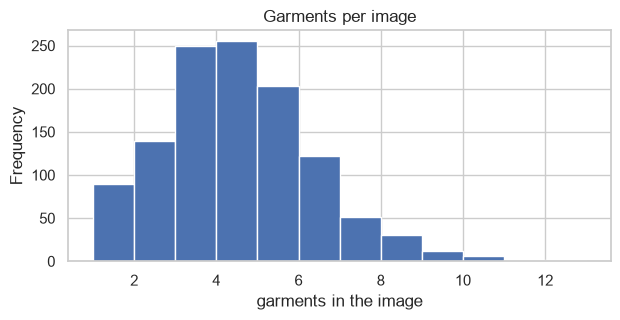

In [13]:
per_image = garments.groupby("image_id").size()
print(per_image.describe().round(2))
ax = per_image.plot.hist(bins=range(1, per_image.max() + 2), figsize=(7, 3), title="Garments per image")
ax.set_xlabel("garments in the image");

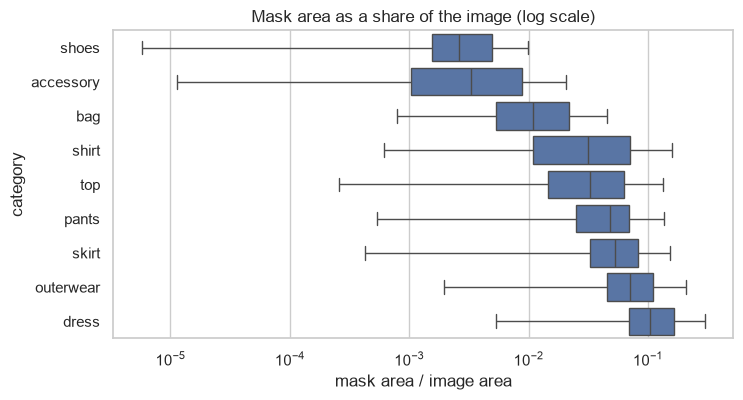

In [14]:
order = garments.groupby("category").area_frac.median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=garments, x="area_frac", y="category", order=order, showfliers=False, ax=ax)
ax.set_xscale("log")
ax.set_title("Mask area as a share of the image (log scale)")
ax.set_xlabel("mask area / image area");

In [16]:
# share of tiny objects per class: under 0.5% of the image is roughly smaller than 45x45 px at 640 px
size = garments.groupby("category").area_frac.agg(
    median="median",
    tiny_share=lambda a: (a < 0.005).mean(),
).round(4).sort_values("median")
size

,median,tiny_share
category,,
shoes,0.0026,0.7567
accessory,0.0033,0.6185
bag,0.0109,0.2243
shirt,0.0317,0.1176
top,0.0325,0.0843
pants,0.0478,0.0405
skirt,0.0529,0.0185
outerwear,0.0709,0.0064
dress,0.1048,0.0000


### Image resolution and aspect ratio
To choose the training image size.

In [74]:
print(images[["width", "height", "aspect"]].describe().round(2))
print("\nmost common sizes:")
print(images.groupby(["width", "height"]).size().sort_values(ascending=False).head(8))

         width   height   aspect
count  1158.00  1158.00  1158.00
mean    750.74   962.38     0.82
std     147.89   131.86     0.33
min     415.00   471.00     0.41
25%     681.00  1024.00     0.67
50%     682.00  1024.00     0.67
75%     768.00  1024.00     0.75
max    1024.00  1024.00     2.17

most common sizes:
width  height
682    1024      306
683    1024      200
1024   682        77
680    1024       60
1024   683        53
681    1024       53
632    1024       33
633    1024       29
dtype: int64


portrait: 79%, landscape: 19%


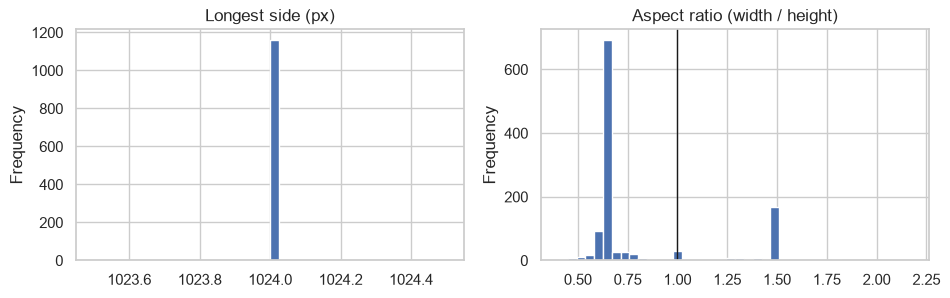

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
images["max_side"] = images[["width", "height"]].max(axis=1)
images.max_side.plot.hist(bins=40, ax=axes[0], title="Longest side (px)")
images.aspect.plot.hist(bins=40, ax=axes[1], title="Aspect ratio (width / height)")
axes[1].axvline(1, color="k", lw=1);
print(f"portrait: {(images.aspect < 1).mean():.0%}, landscape: {(images.aspect > 1).mean():.0%}")

### Attribute coverage
How many garments actually have each attribute labelled? Only counted for the categories in the attribute's `applies_to`.

Colour, formality and warmth are not in Fashionpedia at all, so they show 0.

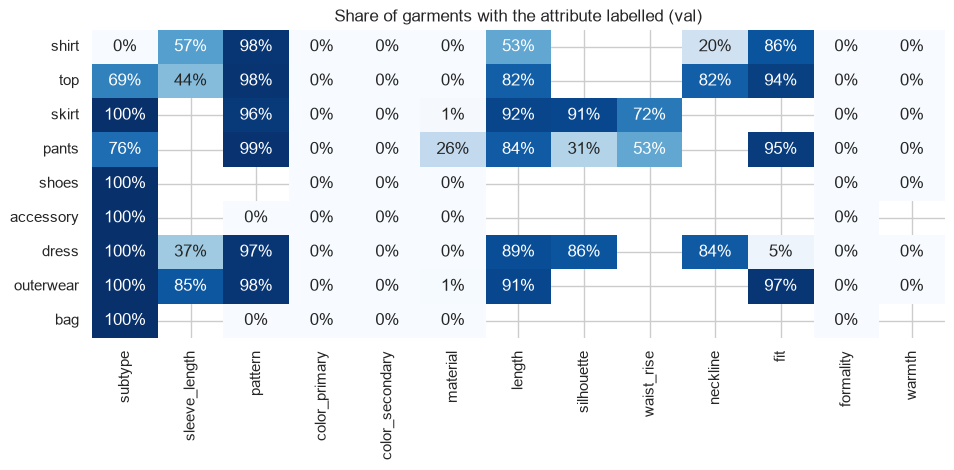

In [19]:
attrs = [a for a in taxonomy["attributes"]]
cov = {}
for attr in attrs:
    applies = taxonomy["attributes"][attr]["applies_to"]
    col = garments[attr] if attr in garments else pd.Series(np.nan, index=garments.index)
    cov[attr] = {cat: col[garments.category == cat].notna().mean() if cat in applies else np.nan
                 for cat in taxonomy["categories"]}
coverage = pd.DataFrame(cov)  # rows: category, columns: attribute; blank = does not apply

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(coverage, annot=True, fmt=".0%", cmap="Blues", vmin=0, vmax=1, cbar=False, ax=ax)
ax.set_title(f"Share of garments with the attribute labelled ({SPLIT})");

In [21]:
# labelled garments per attribute value: which values are too rare to learn?
for attr in ["pattern", "fit", "length", "silhouette", "waist_rise", "sleeve_length", "neckline", "material"]:
    print(f"{attr:14}", garments[attr].value_counts().to_dict())

pattern        {'solid': 1543, 'abstract': 107, 'floral': 95, 'striped': 78, 'checked': 57, 'other': 35, 'polka_dot': 29, 'graphic': 26, 'animal_print': 17, 'camouflage': 7}
fit            {'regular': 630, 'skinny': 436, 'loose': 212, 'oversized': 16, 'baggy': 7}
length         {'mini': 522, 'above_hip': 506, 'maxi': 375, 'hip': 142, 'knee': 113, 'midi': 71}
silhouette     {'straight': 236, 'flare': 150, 'pencil': 133, 'a_line': 101, 'fit_and_flare': 60, 'wide_leg': 51}
waist_rise     {'mid': 197, 'high': 88, 'low': 54}
sleeve_length  {'long': 430, 'short': 230, 'three_quarter': 77, 'sleeveless': 8}
neckline       {'round': 319, 'boat': 134, 'v_neck': 114, 'scoop': 108, 'sweetheart': 58, 'high': 44, 'other': 39, 'off_shoulder': 21, 'square': 20, 'halter': 15, 'one_shoulder': 9}
material       {'denim': 109, 'suede': 4, 'leather': 2}


### Sleeves and necklines
These come from separate part objects matched to their garment by box overlap.
A top/shirt/dress/outerwear garment with **0 sleeves** matched is probably sleeveless (Fashionpedia rarely labels `sleeveless` itself).

In [22]:
sleeve_cats = taxonomy["attributes"]["sleeve_length"]["applies_to"]
s = garments[garments.category.isin(sleeve_cats)]
pd.DataFrame({
    "sleeves_matched_0": s.groupby("category").n_sleeves.apply(lambda n: (n == 0).mean()),
    "sleeves_matched_2": s.groupby("category").n_sleeves.apply(lambda n: (n == 2).mean()),
    "has_sleeve_length": s.groupby("category").sleeve_length.apply(lambda v: v.notna().mean()),
}).round(2)

,sleeves_matched_0,sleeves_matched_2,has_sleeve_length
category,,,
dress,0.61,0.31,0.37
outerwear,0.13,0.72,0.85
shirt,0.41,0.46,0.57
top,0.56,0.39,0.44


### How different are these images from what users will upload?
Look at random images with the mapped boxes drawn. Compare with your own phone photos: hanging, flat-lay, mirror selfies, shop screenshots.

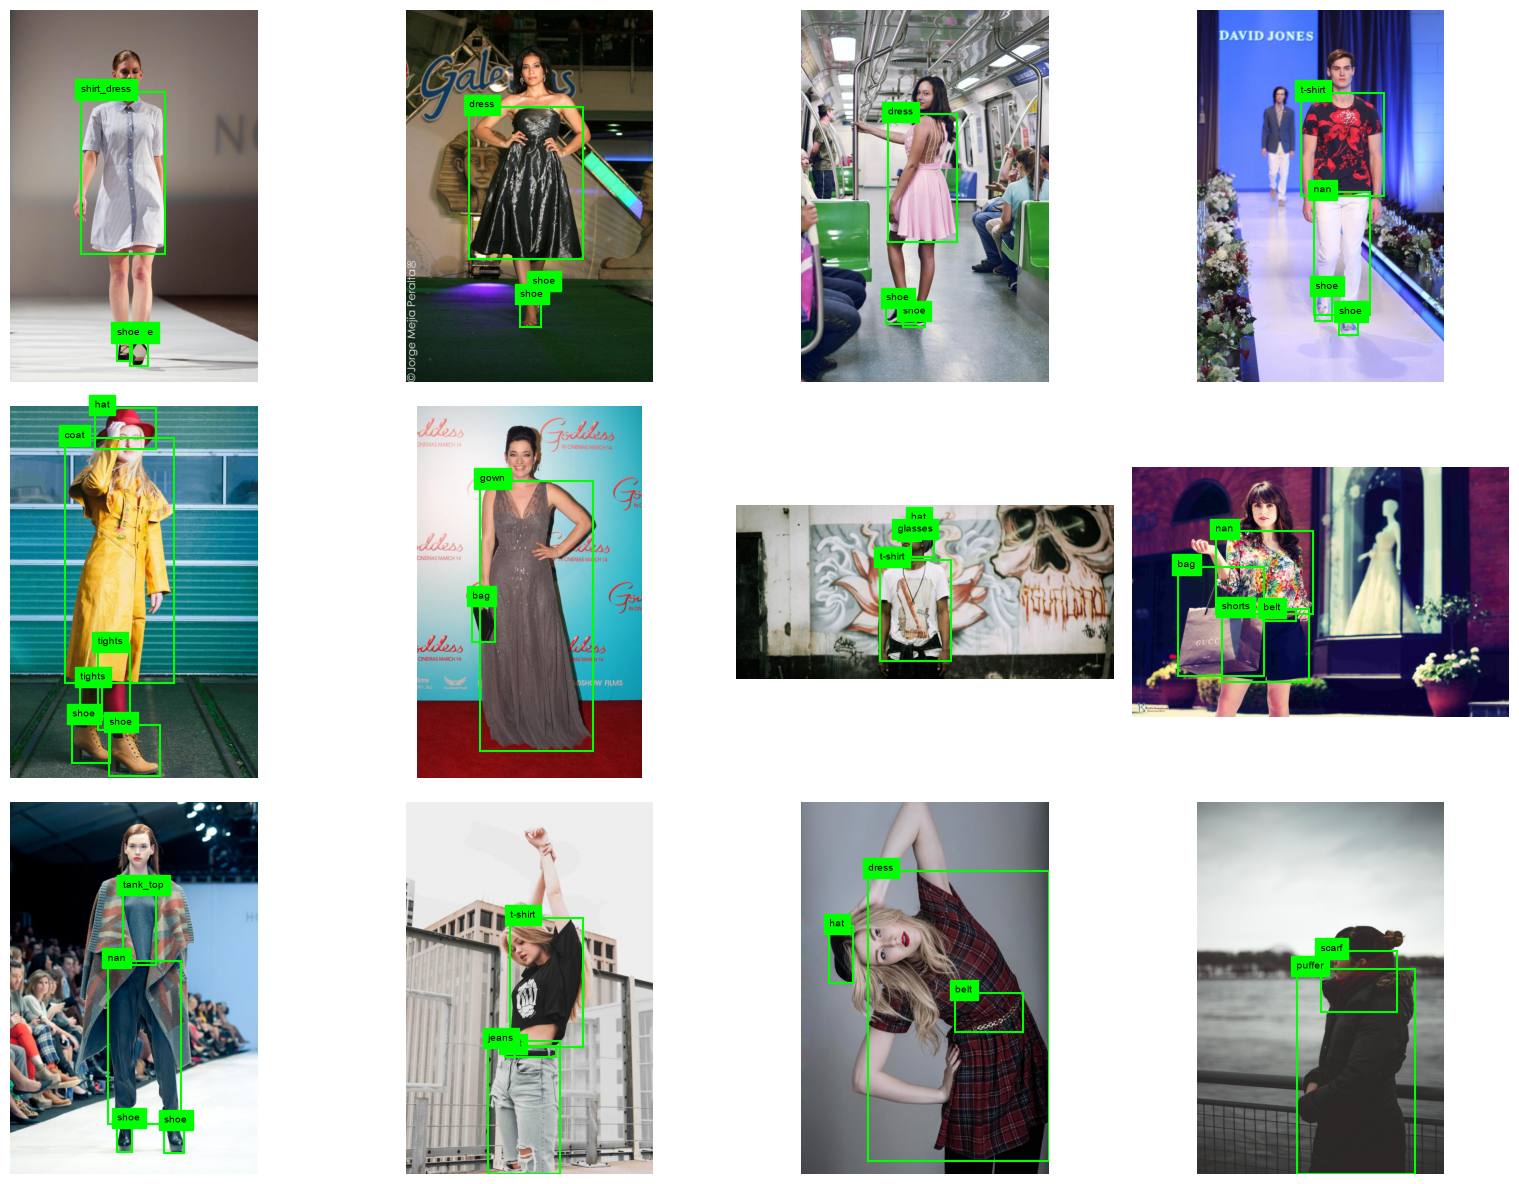

In [23]:
from PIL import Image
import matplotlib.patches as patches

def show_image(image_id, ax):
    img = images.set_index("image_id").loc[image_id]
    ax.imshow(Image.open(IMAGE_DIR / img.file_name))
    for g in garments[garments.image_id == image_id].itertuples():
        ax.add_patch(patches.Rectangle((g.bbox_x, g.bbox_y), g.bbox_w, g.bbox_h, fill=False, lw=1.5, color="lime"))
        ax.text(g.bbox_x, g.bbox_y, g.subtype or g.category, fontsize=7, color="black", backgroundcolor="lime")
    ax.axis("off")

sample = garments.image_id.drop_duplicates().sample(12, random_state=0)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for image_id, ax in zip(sample, axes.flat):
    show_image(image_id, ax)
plt.tight_layout()